In [ ]:
## mac-korrektur ###
%pip install "numpy<2.0" --force-reinstall
%pip install gensim --upgrade

In [ ]:
%pip install pymupdf nltk matplotlib pandas numpy

In [ ]:
##### Schritt 1, Option 1: Text herunterladen ###
#################################################
import requests

def download_gutenberg_book(url):
    print(f"Lade Text herunter von: {url}...")
    response = requests.get(url)
    
    # Prüfen, ob der Download erfolgreich war (HTTP Status 200 = OK)
    if response.status_code == 200:
        full_text = response.text
        
        # Projekt Gutenberg fügt immer lange rechtliche Hinweise an den Anfang und das Ende.
        # Diese wollen wir für unser Word2Vec-Training herausschneiden.
        start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
        end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"
        
        # Suchen, wo diese Marker im Text stehen
        start_idx = full_text.find(start_marker)
        end_idx = full_text.find(end_marker)
        
        if start_idx != -1 and end_idx != -1:
            # Wir springen zum Ende des Start-Markers (plus Zeilenumbruch)
            start_idx = full_text.find('\n', start_idx) + 1
            clean_text = full_text[start_idx:end_idx].strip()
            print("Download und Bereinigung erfolgreich!")
            return clean_text
        else:
            print("Warnung: Gutenberg-Marker nicht gefunden. Gebe gesamten Text zurück.")
            return full_text
    else:
        raise Exception(f"Fehler beim Download. Status Code: {response.status_code}")

# Die Gutenberg-URL für Grimms Märchen (Buch ID: 77905)
#book_url = "https://www.gutenberg.org/cache/epub/77905/pg77905.txt"

# Die Buddenbrooks von Thomas Mann (Buch ID: 34811)
book_url = "https://www.gutenberg.org/cache/epub/34811/pg34811.txt"

# Text herunterladen
raw_text = download_gutenberg_book(book_url)

# Text lokal speichern
with open("Datasets/textcorpus.txt", "w", encoding="utf-8") as file:
    file.write(raw_text)

# Eine kurze Vorschau (wir überspringen die ersten Zeichen, um das Inhaltsverzeichnis zu umgehen)
print(f"\nDer bereinigte Text hat {len(raw_text)} Zeichen.")
print("\n--- Vorschau ---")
print(raw_text[6500:7000])

In [ ]:
###### Schritt 1, Option 2: PDF-Extraktion ######
#################################################
import fitz
import re

def extract_clean_text(pdf_path, start_page=0, end_page=None):
    # Öffne das PDF-Dokument
    doc = fitz.open(pdf_path)
    full_text = ""
    
    # Automatische Anpassung der Seitenanzahl
    if end_page is None or end_page > doc.page_count:
        end_page = doc.page_count
        
    print(f"Das Dokument hat {doc.page_count} Seiten. Extrahiere Seiten {start_page} bis {end_page - 1}...")
    
    # Iteriere über die tatsächlich existierenden Seiten
    for page_num in range(start_page, end_page):
        page = doc.load_page(page_num)
        raw_text = page.get_text("text")
        
        # 1. Silbentrennung am Zeilenende reparieren
        clean_text = re.sub(r'-\s*\n\s*', '', raw_text)
        
        # 2. Übrige harte Zeilenumbrüche durch ein einzelnes Leerzeichen ersetzen
        clean_text = clean_text.replace('\n', ' ')
        
        # 3. Mehrfache Leerzeichen reduzieren
        clean_text = re.sub(r'\s+', ' ', clean_text)
        
        # Text der Seite an den Gesamttext anhängen
        full_text += clean_text + " "
        
    print(f"Extraktion abgeschlossen. Zeichenanzahl: {len(full_text)}")
    return full_text

# Ausführen der Funktion (liest jetzt standardmäßig alle Seiten!)
pdf_datei = "Datasets/Sunzi.pdf"
text = extract_clean_text(pdf_datei)

# Text in eine Datei schreiben
with open("Datasets/textcorpus.txt", "w", encoding="utf-8") as file:
    file.write(text)

# Einen kurzen Blick auf die ersten 500 Zeichen werfen, um das Ergebnis zu prüfen
print("\n--- Vorschau ---")
print(text[:500])

In [ ]:
### Schritt 2: lokal gespeicherten Text laden ###
#################################################

def load_local_text(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        return file.read()
    
# Beispiel: Text aus einer lokalen Datei laden
#local_text_path = "Datasets/grimms_maerchen.txt"
local_text_path = "Datasets/textcorpus.txt"
raw_text = load_local_text(local_text_path)
print(f"\nDer lokale Text hat {len(raw_text)} Zeichen.")

In [ ]:
###### Download-Problem temporär umgehen ########
#################################################
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
### Schritt 3, Option 1: Stopwords drin lassen, aber Satzzeichen entfernen ###
##############################################################################

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

# WICHTIG: NLTK benötigt einmalig bestimmte Sprachmodelle, um zu wissen, 
# wo im Deutschen Sätze und Wörter enden.
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    nltk.download('punkt_tab') # Manchmal für neuere NLTK-Versionen nötig

def preprocess_text(raw_text):
    """
    Zerlegt den Text in Sätze und Wörter, wandelt alles in Kleinbuchstaben um
    und filtert reine Satzzeichen heraus.
    """
    print("Starte NLP-Preprocessing...")
    
    # 1. Text in Sätze aufteilen (mit deutschem Sprachmodell)
    sentences = sent_tokenize(raw_text, language='german')
    
    corpus_sentences = []
    
    for sentence in sentences:
        # 2. Satz in einzelne Wörter (Token) aufteilen
        words = word_tokenize(sentence, language='german')
        
        # 3. Bereinigung: Kleinschreibung und nur Wörter behalten (keine Satzzeichen/Zahlen)
        # .isalpha() prüft, ob der String nur aus Buchstaben (inkl. Umlauten) besteht.
        clean_words = [word.lower() for word in words if word.isalpha()]
        
        # Leere Sätze ignorieren (passiert manchmal bei reinen Formatierungszeilen)
        if len(clean_words) > 0:
            corpus_sentences.append(clean_words)
            
    print(f"Preprocessing abgeschlossen. {len(corpus_sentences)} Sätze extrahiert.")
    return corpus_sentences

# Ausführen der Funktion mit unserem Text aus Schritt 1
corpus = preprocess_text(raw_text)

# Einen kurzen Blick auf die ersten 3 Sätze werfen
print("\n--- Vorschau der Trainingsdaten ---")
for i, sent in enumerate(corpus[:3]):
    print(f"Satz {i+1}: {sent}")

In [ ]:
### Schritt 3, Option 2: Stopwords entfernen und Wörter normalisieren ###
#########################################################################

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

# Sprachmodelle und Stopwort-Listen herunterladen
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('punkt')
    nltk.download('punkt_tab')
    nltk.download('stopwords')

# Deutsche Stopwords laden und in ein Set umwandeln (Sets sind beim Filtern viel schneller)
german_stop_words = set(stopwords.words('german'))

# Zusätzliche "Störwörter" und plattdeutsche Begriffe für Grimm's Märchen
custom_stop_words = {
    "sagte", "sprach", "schon", "ging", "kam", "wohl", "wer", "daß", 
    "dat", "de", "un", "he", "se", "ik", "up", "as", "nich", "fru", "säd", "sä", "do", "vun"
}
german_stop_words = german_stop_words.union(custom_stop_words)

def preprocess_text(raw_text):
    """
    Zerlegt den Text in Sätze und Wörter, wandelt alles in Kleinbuchstaben um,
    filtert reine Satzzeichen UND Stopwords heraus.
    """
    print("Starte NLP-Preprocessing mit Stopword-Filter...")
    sentences = sent_tokenize(raw_text, language='german')
    corpus_sentences = []
    
    for sentence in sentences:
        words = word_tokenize(sentence, language='german')
        
        # Die magische Zeile: Nur alphabetische Wörter behalten UND 
        # prüfen, ob das Wort NICHT in unserer Stopwort-Liste ist.
        clean_words = [
            word.lower() for word in words 
            if word.isalpha() and word.lower() not in german_stop_words
        ]
        
        if len(clean_words) > 0:
            corpus_sentences.append(clean_words)
            
    print(f"Preprocessing abgeschlossen. {len(corpus_sentences)} Sätze extrahiert.")
    return corpus_sentences

# Funktion ausführen (angenommen, 'raw_text' existiert aus dem PDF- oder Gutenberg-Download)
corpus = preprocess_text(raw_text)

# Einen kurzen Blick auf die Trainingsdaten werfen
print("\n--- Vorschau der gefilterten Trainingsdaten ---")
for i, sent in enumerate(corpus[:3]):
    print(f"Satz {i+1}: {sent}")

In [37]:
########### Schritt 4: Modell trainieren ########
#################################################

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import Word2Vec

# 1. Word2Vec Modell trainieren
print("Trainiere Word2Vec Modell...")
model = Word2Vec(
    sentences=corpus,
    vector_size=200,  # Größe des Vektors (Dimensionen)
    window=100,        # Kontext-Fenster
    min_count=2,      # Ignoriere Wörter, die nur 1x im ganzen Buch vorkommen
    workers=4,        # Nutze 4 CPU-Kerne
    epochs=100,       # Da unser Text (64 Seiten) recht kurz ist, helfen mehr Epochen beim Lernen
    sg=1              # Skip-Gram Modell (1) oder CBOW (0)
)

print("Training abgeschlossen!")

Trainiere Word2Vec Modell...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Training abgeschlossen!


In [38]:
#### Schritt 4, Optional: Modell speichern ######
#################################################
model.save("Modelle/word2vec_model.model")


Die ähnlichsten Wörter zu 'grünlich':
 - herr: 0.4739
 - erika: 0.3819
 - vornübergebeugt: 0.3796
 - weltläufiger: 0.3786
 - angehalten: 0.3693
 - kesselmeyer: 0.3605
 - gewährt: 0.3561
 - hüstelte: 0.3553
 - reise: 0.3502
 - familienkreis: 0.3495

Die an wenigsten ähnlichen Wörter zu 'grünlich':
 - mut: 0.1132
 - befreit: 0.0869
 - könig: 0.0829
 - engel: 0.0817
 - hals: 0.0705
 - erloschen: 0.0680
 - verstummt: 0.0651
 - hinten: 0.0645
 - possen: 0.0626
 - beobachten: 0.0590

Die häufigkeit von 'grünlich':
254


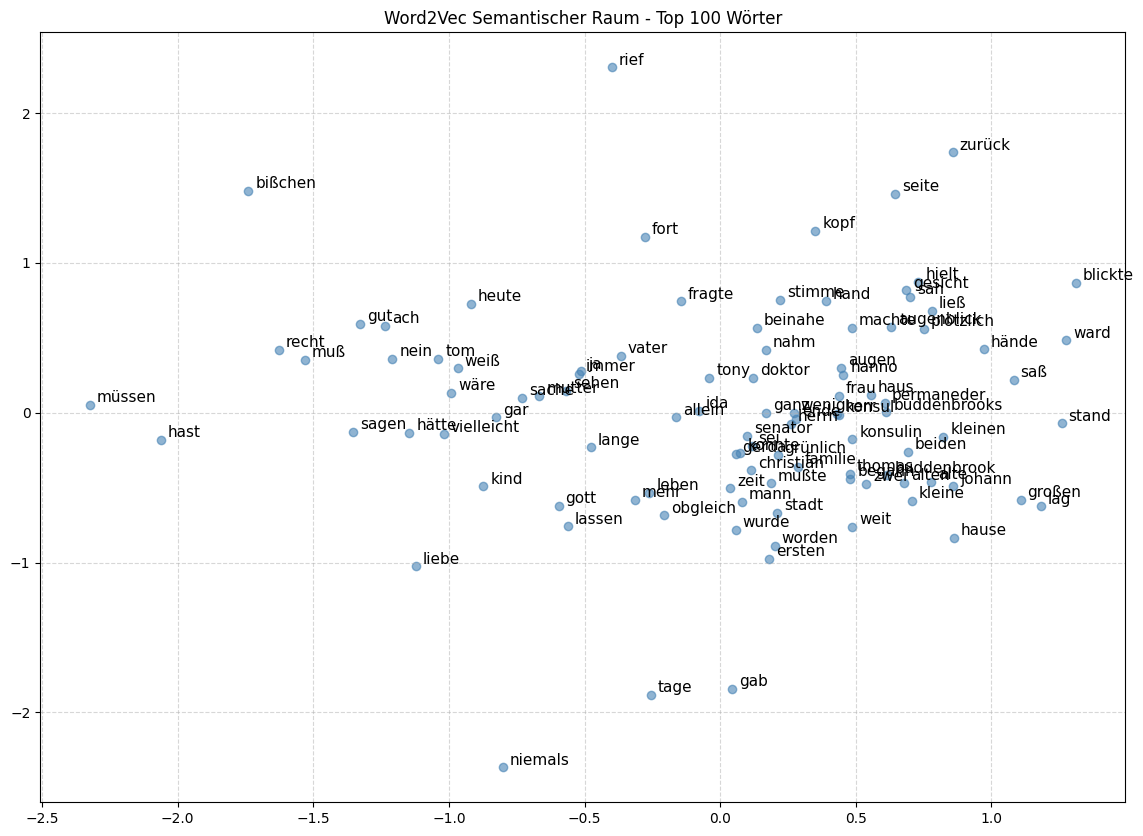

In [53]:
# Schritt 5: Modell testen (Semantische Ähnlichkeit)
####################################################

# Modell laden
model = Word2Vec.load("Modelle/word2vec_model.model")

# Wir testen ein Wort, von dem wir wissen, dass es existiert
test_word = "grünlich" 
if test_word in model.wv.key_to_index:
    print(f"\nDie ähnlichsten Wörter zu '{test_word}':")
    similar_words = model.wv.most_similar(test_word, topn=10)
    for word, similarity in similar_words:
        print(f" - {word}: {similarity:.4f}")

# die am wenigsten ähnlichen wörter:
if test_word in model.wv.key_to_index:
    print(f"\nDie an wenigsten ähnlichen Wörter zu '{test_word}':")
    #similar_words = model.wv.most_similar(test_word, topn=10)
    not_similar_words = model.wv.most_similar(negative=[test_word], topn=10)
    for word, similarity in not_similar_words:
        print(f" - {word}: {similarity:.4f}")
        
# die häufigkeit von wörtern:
print(f"\nDie häufigkeit von '{test_word}':")
print(model.wv.get_vecattr(test_word, "count"))

# 3. PCA Visualisierung (Repariert & Übersichtlich)
def plot_pca(model, top_n=100):
    # Die N häufigsten Wörter extrahieren
    words = list(model.wv.index_to_key)[:top_n]
    
    # die N ähnlichsten Wörter zu einem Wort extrahieren
    #words = [word for word, _ in model.wv.most_similar(test_word, topn=top_n)]
    
    # Vektoren für diese Wörter abrufen
    vectors = np.array([model.wv[word] for word in words])
    
    # Dimensionalität von 100 auf 2 reduzieren
    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)
    
    # Plot konfigurieren
    plt.figure(figsize=(14, 10))
    plt.scatter(result[:, 0], result[:, 1], alpha=0.6, color='steelblue')
    
    # Wörter an die Punkte schreiben
    for i, word in enumerate(words):
        plt.annotate(
            word, 
            xy=(result[i, 0], result[i, 1]), 
            xytext=(5, 2),
            textcoords='offset points',
            fontsize=11
        )
        
    plt.title(f"Word2Vec Semantischer Raum - Top {top_n} Wörter")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Plot ausführen
plot_pca(model, top_n=100)

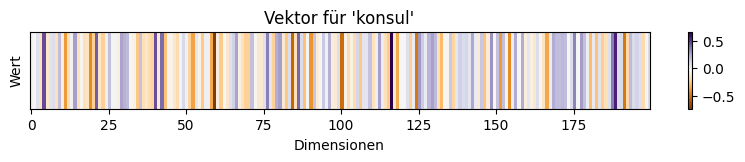

In [40]:
### Schritt 5, optional: Vektoren visualsieren  ###

# Modell laden
model = Word2Vec.load("Modelle/word2vec_model.model")

import numpy as np
### Vektor für ein Wort anzeigen ###
word = "konsul"
vector = np.array(model.wv[word])
#print(f"Vektor für '{word}':\n{vector}")

### mit matplotlib als barcode visualisieren ###
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 1))
plt.imshow(vector.reshape(1, -1), cmap='PuOr', aspect='auto')
plt.colorbar()
plt.title(f"Vektor für '{word}'")
plt.xlabel("Dimensionen")
plt.ylabel("Wert")
plt.yticks([])

plt.show()

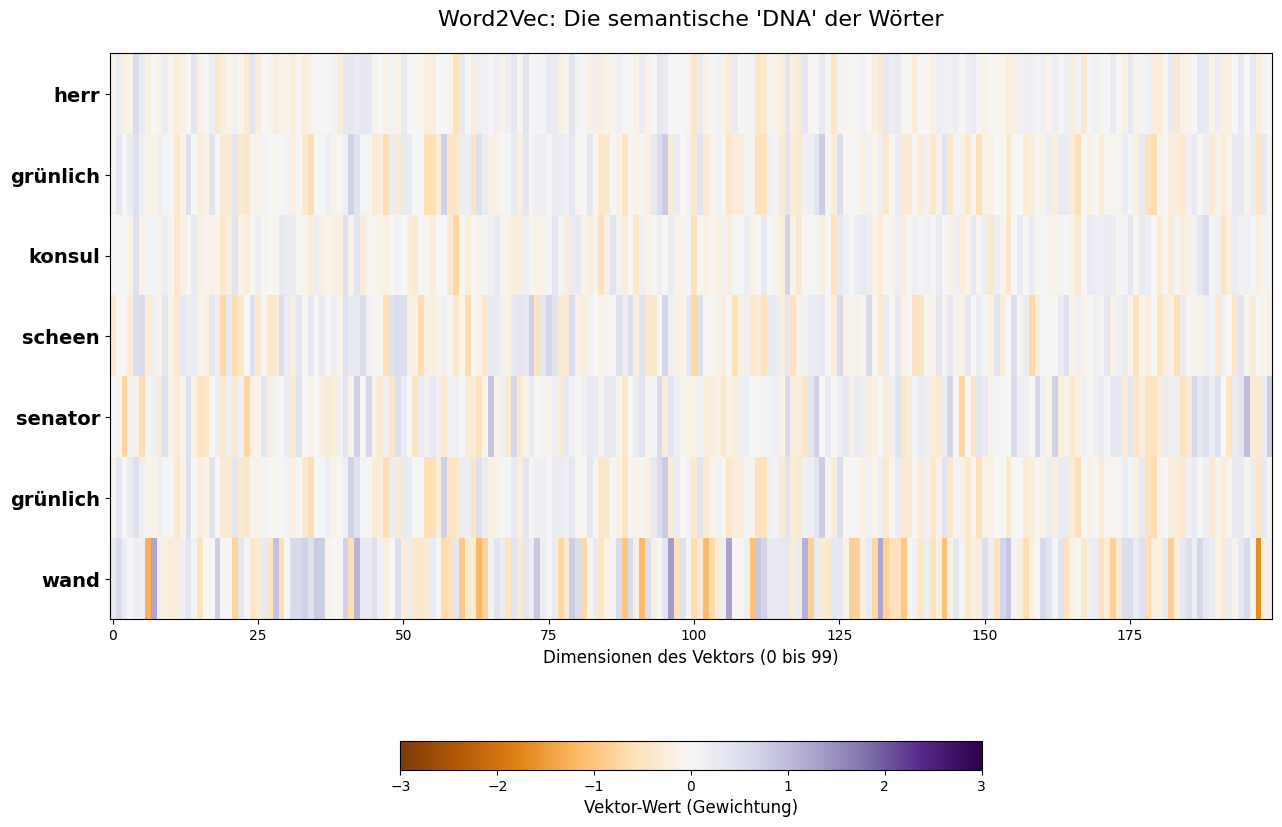

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def plot_vector_barcodes(words, model):
    """
    Visualisiert die hochdimensionalen Vektoren einer Liste von Wörtern als Farb-Barcodes.
    """
    # 1. Prüfen, welche der angefragten Wörter das Modell überhaupt kennt
    valid_words = [w for w in words if w in model.wv.key_to_index]
    
    if not valid_words:
        print("Keines der Wörter ist im Vokabular.")
        return
        
    # 2. Die Vektoren (Zahlen-Arrays) aus dem Modell extrahieren
    vectors = np.array([model.wv[w] for w in valid_words])
    
    # 3. Den Plot aufbauen (Die Höhe passt sich dynamisch an die Anzahl der Wörter an)
    fig, ax = plt.subplots(figsize=(15, 1.5 * len(valid_words)))
    
    # imshow (Image Show) wandelt unsere Matrix aus Zahlen in Pixel um.
    # cmap='PuOr' (Purple-Orange) entspricht in etwa deinem Bild-Beispiel.
    # Alternativen: 'coolwarm', 'RdYlBu' oder 'BrBG'
    # vmin und vmax sorgen dafür, dass die Farbskala bei allen Wörtern gleich geeicht ist
    im = ax.imshow(vectors, cmap='PuOr', aspect='auto', interpolation='nearest', vmin=-3, vmax=3)
    
    # 4. Achsen hübsch machen
    ax.set_yticks(np.arange(len(valid_words)))
    ax.set_yticklabels(valid_words, fontsize=14, fontweight='bold')
    
    ax.set_xlabel("Dimensionen des Vektors (0 bis 99)", fontsize=12)
    ax.set_title("Word2Vec: Die semantische 'DNA' der Wörter", fontsize=16, pad=20)
    
    # 5. Einen Farbbalken (Legende) hinzufügen, damit man sieht, welcher Wert welcher Farbe entspricht
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.15, shrink=0.5)
    cbar.set_label("Vektor-Wert (Gewichtung)", fontsize=12)
    
    plt.show()

# --- Beispielaufruf für das Grimms-Märchen Modell ---
# Wir testen zwei ähnliche und zwei unähnliche Wörter
test_woerter = ["herr", "grünlich", "konsul", "scheen", "senator", "grünlich", "wand"]
plot_vector_barcodes(test_woerter, model)